# 03 – Damping Sweep: Under-, Critically, and Over-Damped

**Manufacturing context:** When commissioning a servo axis, the damping setting determines whether motion is sluggish (overdamped), fast with ringing (underdamped), or optimal (critically damped).

We vary `zeta` while keeping the natural frequency `wn` constant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
m = 1.0       # Mass [kg]
k = 16.0      # Stiffness [N/m]
F_step = 1.0  # Step force [N]
t_end = 6.0   # Simulation duration [s]
dt = 0.001    # Time step [s]

# Damping cases: { label: zeta }
# Critical damping: c_crit = 2 * sqrt(k * m)
zeta_cases = {
    "Underdamped (zeta=0.2)": 0.2,
    "Critically damped (zeta=1.0)": 1.0,
    "Overdamped (zeta=2.0)": 2.0,
}
# -----------------------------

In [2]:
wn = np.sqrt(k / m)
t = np.arange(0, t_end, dt)
responses = {}

for label, zeta in zeta_cases.items():
    c = 2 * zeta * np.sqrt(k * m)
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    for i in range(1, len(t)):
        a = (F_step - c * v[i-1] - k * x[i-1]) / m
        v[i] = v[i-1] + a * dt
        x[i] = x[i-1] + v[i] * dt
    responses[label] = x
    print(f"{label:35s}  c = {c:.2f} N*s/m")

print(f"\nNatural frequency wn = {wn:.2f} rad/s (same for all cases)")

Underdamped (zeta=0.2)               c = 1.60 N*s/m
Critically damped (zeta=1.0)         c = 8.00 N*s/m
Overdamped (zeta=2.0)                c = 16.00 N*s/m

Natural frequency wn = 4.00 rad/s (same for all cases)


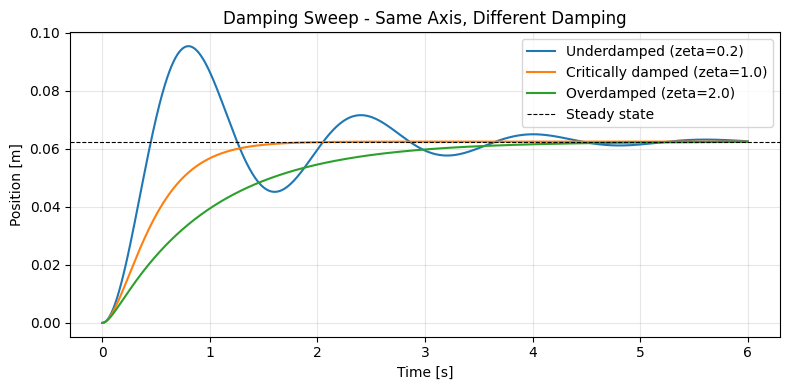

In [3]:
plt.figure(figsize=(8, 4))
for label, x in responses.items():
    plt.plot(t, x, label=label)
plt.axhline(F_step / k, color="k", linestyle="--", linewidth=0.8, label="Steady state")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Damping Sweep - Same Axis, Different Damping")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Student Exercise

1. Add a fourth case: `"Lightly damped (zeta=0.05)": 0.05` to the `zeta_cases` dict and re-run.
2. Which damping ratio would you choose for a pick-and-place robot arm? Why?
3. What happens if `zeta = 0`? Try it.